In [1]:
#!/usr/bin/env julia
using ArgParse
using Dates
using JLD2
using Printf
using Plots

using StatsBase
using Graphs
using SimpleWeightedGraphs
using GraphsMatching

const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

track_domains (generic function with 1 method)

In [2]:
function make_decoder(algo, q, c)
    if algo == "MV"
        return MajorityVote()
    elseif algo == "TOOM"
        return Toom()
    elseif algo == "UV"
        return UnanimousVote()
    elseif algo == "IsingML"
        isnan(c) && error("IsingML requires --c")
        return IsingML(q, c)
    else
        error("Unknown --algo=$(algo)")
    end
end

make_decoder (generic function with 1 method)

In [ ]:
# data = Dict{Tuple{Int, Int, Float64, Float64, Float64}, Tuple{Vector, Vector, Vector, Vector, Vector, Vector, Matrix, Matrix}}()

Dict{Tuple{Int64, Int64, Float64, Float64, Float64}, Tuple{Vector, Vector, Vector, Vector, Vector, Vector, Matrix, Matrix}}()

In [34]:
algo = "IsingML"
L = 8
T = 2L
p, q, c = 0.3, 0.1, 0.8
samples = 1000
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample(L, T, p, q, decoder, samples)
dt = time() - t0

# data[(L, T, p, q, c)] = (M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist)

cumulative_failures[end]

0.68

In [28]:
data[(8, 16, 0.3,0.1,0.8)][6][end]

0.6879

In [22]:
typeof(Ms_hist)

Matrix{Int32} (alias for Array{Int32, 2})

In [12]:
algo = "IsingML"
L = 16
T = 2L
p, q, c = 0.3, 0.1, 0.8
samples = 100
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample(L, T, p, q, decoder, samples)
dt = time() - t0

33.98724293708801

In [56]:
algo = "IsingML"
L = 32
T = L
p, q, c = 0.4, 0.05, 1.0
samples = 1
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample(L, T, p, q, decoder, samples)
dt = time() - t0

14.595836877822876

In [57]:
3*20*1000/60/60

16.666666666666668

In [21]:
algo = "IsingML"
L = 24
T = 2L
p = 0.05
qs = 0.1:0.01:0.3
cs = 0.0:0.05:0.25

dts = Dict{Tuple{Float64,Float64,Float64},Float64}()

for q in qs
    for c in cs
    samples = 1
    tag     = "test"

    decoder = make_decoder(algo, q, c)

    # Warmup to avoid timing JIT compilation
    sample(2, 2, 0.0, 0.0, decoder, 1)

    t0 = time()
    M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample(L, T, p, q, decoder, samples)
    dt = time() - t0
    dts[(p,q,c)] = dt
    end
end

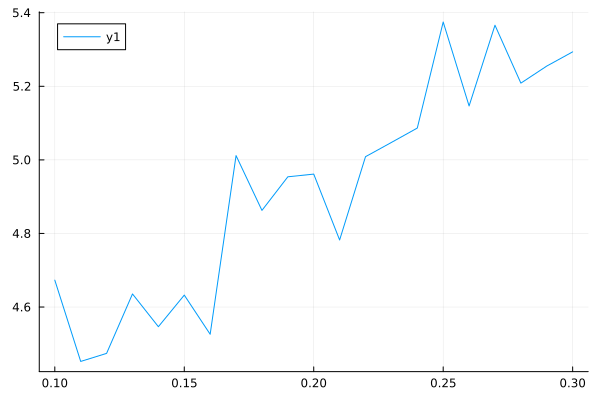

In [31]:
p = 0.05
qs = 0.1:0.01:0.3
c = 0.15

plt = plot()
plot!(plt, qs, [dts[(p,q,c)] for q in qs])